In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 读取你的文件
df = pd.read_csv("crawl_parts/edges_all.csv")

print("Rows:", len(df))
print("Unique matches:", df["matchId"].nunique())
print("Unique players:", len(set(df["u_puuid"]) | set(df["v_puuid"])))
G = nx.Graph()
for u, v in zip(df["u_puuid"], df["v_puuid"]):
    G.add_edge(u, v)

Rows: 73480
Unique matches: 3674
Unique players: 18344


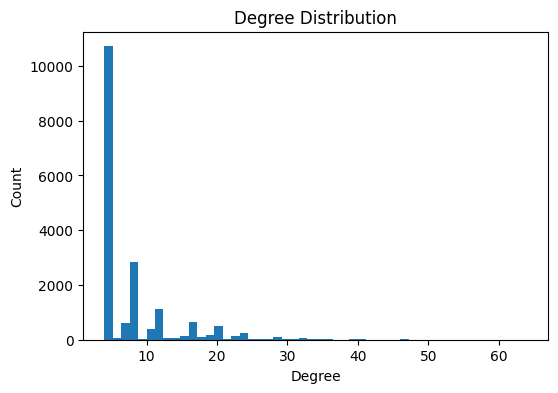

In [7]:
degrees = dict(G.degree())
deg_values = np.array(list(degrees.values()))
plt.figure(figsize=(6,4))
plt.hist(deg_values, bins=50)
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree Distribution")
plt.show()

In [8]:

components = list(nx.connected_components(G))
gcc = max(components, key=len)

print("Total components:", len(components))
print("GCC size:", len(gcc))
print("GCC ratio:", len(gcc)/G.number_of_nodes())


Total components: 186
GCC size: 17373
GCC ratio: 0.947067160924553


In [9]:
G_gcc = G.subgraph(gcc)

avg_path = nx.average_shortest_path_length(G_gcc)
print("Average shortest path length (GCC):", avg_path)


Average shortest path length (GCC): 5.571487566244868


In [10]:
assort = nx.degree_assortativity_coefficient(G)
print("Degree assortativity:", assort)



Degree assortativity: 0.12163633184832921


队友多样性高的玩家，更倾向于和队友多样性高的玩家同队?


In [11]:
import networkx as nx
import random

def degree_preserving_null(G: nx.Graph, nswap_per_edge: int = 10, max_tries_factor: int = 50, seed: int = 0) -> nx.Graph:
    """
    Degree-preserving null model via double-edge swaps.
    Keeps the exact degree of every node (for simple undirected graphs).

    Parameters
    ----------
    G : nx.Graph
        Simple undirected graph.
    nswap_per_edge : int
        Target swap count = nswap_per_edge * |E|.
        Typical: 5~20.
    max_tries_factor : int
        max_tries = max_tries_factor * nswap.
    seed : int
        Random seed.

    Returns
    -------
    H : nx.Graph
        Degree-preserving randomized graph.
    """
    if G.is_directed():
        raise ValueError("This function is for undirected graphs. Use a directed version for DiGraph.")
    if any(u == v for u, v in G.edges()):
        raise ValueError("Self-loops detected; expected a simple graph.")
    if isinstance(G, nx.MultiGraph):
        raise ValueError("Expected nx.Graph (simple graph), not MultiGraph.")

    H = G.copy()
    rng = random.Random(seed)

    nswap = nswap_per_edge * H.number_of_edges()
    max_tries = max_tries_factor * nswap

    # networkx uses Python's random internally; seed via `seed=...`
    nx.double_edge_swap(H, nswap=nswap, max_tries=max_tries, seed=rng)

    return H


In [12]:
H = degree_preserving_null(G, nswap_per_edge=10, seed=1)

print("Original assort:", nx.degree_assortativity_coefficient(G))
print("Null assort:", nx.degree_assortativity_coefficient(H))

print("Original clustering:", nx.average_clustering(G))
print("Null clustering:", nx.average_clustering(H))


Original assort: 0.12163633184832921
Null assort: -0.0009688426273926642
Original clustering: 0.7220845407014281
Null clustering: 0.0012614708478090892
